# 🏥 CariSurg MedTech Pathways — Week 0, Tutorial 2
## Python for Advanced Data Cleaning
**Mercer General Hospital | Clinical AI & Innovation Unit**

---
> **Day 2 Challenge:** Each breakout group is assigned one column to clean.
> Your group must understand what the column *means clinically* before deciding *how* to clean it.

---
### What we will cover today
1. Key pandas inspection commands
2. Identifying outliers via range checks
3. Handling wrong data types and `NaN` values
4. Imputation methods (mean, median, mode)
5. Connecting data to clinical meaning
6. Breakout group work

**Day 2 Submission:** Your group's cleaning notebook for your assigned column.


## 1. Quick Recap — Useful Inspection Commands

**[TUTOR NOTE — rapid fire demo, ~10 min. Students should follow along in their own notebooks.]**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

df = pd.read_csv(FILE_PATH)

# Re-apply Gender cleaning from Day 1 so we start from a consistent state
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

print(f"Dataset: {df.shape[0]} rows x {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!
Dataset: 2205 rows x 11 columns


In [3]:
# The five most useful inspection commands — run them in order, every time
print("=== head() — first 5 rows ===")
print(df.head())

=== head() — first 5 rows ===
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [4]:
print("=== tail() — last 5 rows (catches truncation issues) ===")
print(df.tail())

=== tail() — last 5 rows (catches truncation issues) ===
        ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR  Fio2
2200  2380   65       1  14.0  170   50.0   90.00   65.0  37.0  22.0  21.0
2201  2381   84       0  15.0  180  120.0  140.00   85.0  36.1  18.0  21.0
2202  2382   78       0  15.0  132   78.0   96.00  100.0  37.9  16.0  21.0
2203  2383   65       1  15.0  140   80.0  100.00   85.0  36.4  16.0  21.0
2204  2384   78       0  15.0  145   90.0  108.33   75.0  37.6  20.0  21.0


In [5]:
print("=== info() — column types and non-null counts ===")
df.info()

=== info() — column types and non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB


In [6]:
print("=== describe() — statistics for numeric columns only ===")
print(df.describe())

=== describe() — statistics for numeric columns only ===
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000    30.000000    39.330000   
25%     577.000000    50.000000     0.000000    70.000000    82.500000   
50%    1135.000000    64.000000     1.000000    78.000000    93.330000   
75%    1703.000000    77.000000     1.000000    87.000000   103.330000   
max    2384.000000    98.000000     1.000000   173.000000   185.000000   

                RR         Fio2  
count  2183.000000  2183.000000  
mean     20.262254    25.019698  
std       5.742333    10.144288  
min      12.000000    21.000000  
25%      17.000000    21.000000  
50%      18.000000    21.000000  
75%      21.000000    21.000000  
max 

In [7]:
print("=== shape — (rows, columns) ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

=== shape — (rows, columns) ===
Rows: 2205, Columns: 11


**[TUTOR NOTE — pause and ask]**
After running `df.info()`:
- Which columns are `object` type but should be numeric?
- What does `non-null count < total rows` tell us?

After running `df.describe()`:
- Point out that only numeric columns appear
- Ask: "What does `min` of -10 for a column mean clinically? Is that possible?"


## 2. Clinical Reference Table

**[TUTOR NOTE — spend 5 minutes here. This is the most important non-code moment of the tutorial.]**
Before cleaning any column, you need to know what valid values look like.
Here is the reference for every column in this dataset:

| Column | Clinical Meaning | Valid Range | Unit |
|--------|-----------------|-------------|------|
| `Age` | Patient age | 0 – 120 | years |
| `Gender` | Biological sex | 0 (Female) or 1 (Male) | encoded |
| `GCS` | Glasgow Coma Scale — consciousness level | 3 – 15 | score |
| `SBP` | Systolic Blood Pressure | 50 – 250 | mmHg |
| `DBP` | Diastolic Blood Pressure | 30 – 150 | mmHg |
| `MAP` | Mean Arterial Pressure — organ perfusion indicator | 40 – 180 | mmHg |
| `pulse` | Heart rate | 20 – 250 | bpm |
| `Temp` | Body temperature | 32.0 – 43.0 | °C |
| `RR` | Respiratory rate | 5 – 60 | breaths/min |
| `Fio2` | Fraction of Inspired Oxygen | 21 – 100 | % |

**Key insight:** The valid range is determined by *physiology*, not by the data.
A `GCS` of 99 is not an outlier — it is an error. They are different things.


## 3. Handling Wrong Data Types

**[TUTOR NOTE — demonstrate GCS, ~10 min]**

In [8]:
# GCS is currently stored as a string (object type)
print("GCS dtype:", df['GCS'].dtype)
print("Unique GCS values:", df['GCS'].unique())

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']


**[TUTOR NOTE — ask students]**
You can see the value `'error'` in the GCS column. Where did that come from?
This happens when data entry systems allow free-text input.
Our job is to decide what to do with it — not ignore it.


In [9]:
# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')

print("After conversion:")
print(f"  dtype: {df['GCS'].dtype}")
print(f"  NaN count: {df['GCS'].isnull().sum()}")
print(f"  Range: {df['GCS'].min()} to {df['GCS'].max()}")

After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0


## 4. Identifying and Handling Outliers

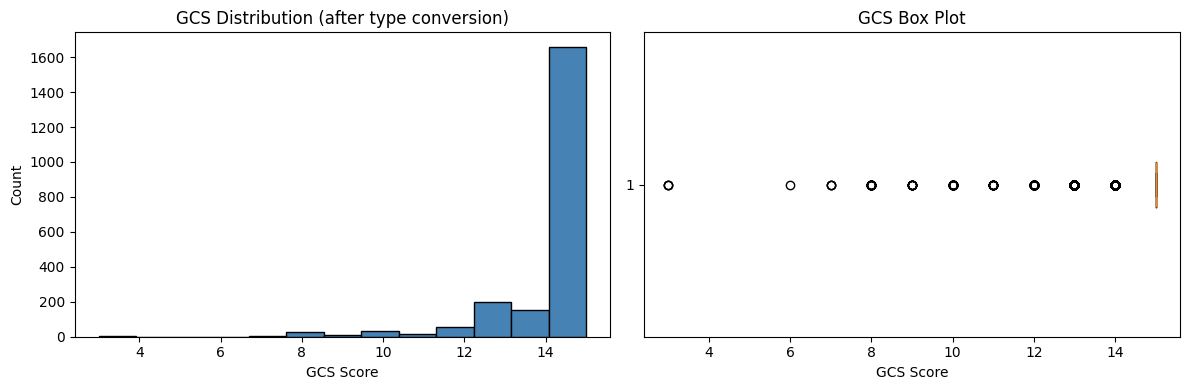

Plot saved as gcs_distribution.png


In [10]:
# Step 1: Visualise BEFORE removing anything
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['GCS'].dropna(), bins=13, edgecolor='black', color='steelblue')
axes[0].set_xlabel('GCS Score')
axes[0].set_ylabel('Count')
axes[0].set_title('GCS Distribution (after type conversion)')

axes[1].boxplot(df['GCS'].dropna(), vert=False)
axes[1].set_xlabel('GCS Score')
axes[1].set_title('GCS Box Plot')

plt.tight_layout()
plt.savefig('gcs_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved as gcs_distribution.png")

**[TUTOR NOTE — ask before running the next cell]**
"GCS is scored 3 to 15. If you saw a GCS value of 2 or 16 in this column, what would you do?"

Key teaching point: There are three options for outliers:
1. **Remove** the row entirely (risky — you lose a real patient)
2. **Replace** with NaN, then impute (common approach)
3. **Cap** at the boundary value (e.g. replace 16 with 15)

Which you choose must be *clinically justified*, not just technically convenient.


In [11]:
# Step 2: Flag physiologically impossible values
# GCS valid range: 3–15
invalid_gcs = df[(df['GCS'] < 3) | (df['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))

GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []


In [12]:
# Step 3: Replace invalid values with NaN
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df['GCS'].isnull().sum()}")

NaN count after range filter: 44


## 5. Imputation — Filling Missing Values

**[TUTOR NOTE — explain the three options before coding, ~5 min]**

Three common imputation strategies:

| Strategy | Use when | Risk |
|----------|----------|------|
| **Mean** | Data is normally distributed, no extreme outliers | Sensitive to outliers — pulls the mean |
| **Median** | Data is skewed or has outliers | More robust, but loses distributional info |
| **Mode** | Categorical or count data | Only works if one value dominates |

For GCS (scored 3–15, skewed toward 15 in most ED populations), the **median** is usually the safer choice.


In [13]:
# Compute the median and use it to fill NaN values
gcs_median = df['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df['GCS'] = df['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df['GCS'].describe())
print(f"Remaining NaNs: {df['GCS'].isnull().sum()}")

GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


## 6. Worked Example — Cleaning the SBP Column

**[TUTOR NOTE — walk through this at pace, ~10 min, as the template groups will follow for their columns]**


In [14]:
# SBP = Systolic Blood Pressure. Valid range: 50–250 mmHg.
# Extremely low SBP (<70) = shock risk. Extremely high (>200) = hypertensive crisis.

print("SBP unique values (sample):", df['SBP'].unique()[:15])
print("SBP dtype:", df['SBP'].dtype)

SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object


In [15]:
# 1. Convert to numeric — non-numeric entries become NaN
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
print("After type conversion:")
print(df['SBP'].describe())

After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64


In [16]:
# 2. Identify out-of-range values
invalid_sbp = df[(df['SBP'] < 50) | (df['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())

Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0


In [17]:
# 3. Replace out-of-range with NaN, then impute with median
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df['SBP'].median()
df['SBP'] = df['SBP'].fillna(sbp_median)

print(f"SBP after cleaning: min={df['SBP'].min()}, max={df['SBP'].max()}, NaNs={df['SBP'].isnull().sum()}")

SBP after cleaning: min=55.0, max=250.0, NaNs=0


## 7. Temperature — A Special Case

**[TUTOR NOTE — this is a great teaching moment about unit inconsistency, ~10 min]**
The `Temp` column has a mix of values: some are plain numbers (Celsius), some have a `'C'` suffix, and some were entered in Fahrenheit.
This is a unit inconsistency error — one of the most common data quality issues in clinical datasets.


In [18]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df['Temp'].unique()[:20])

Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']


In [19]:
# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return np.nan                           # anything else -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].describe())

After standardisation:
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [20]:
# Apply range filter: valid body temperature 32–43°C
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan

# Impute with median
temp_median = round(df['Temp'].median(), 1)
df['Temp'] = df['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df['Temp'].min():.1f}, max={df['Temp'].max():.1f}, NaNs={df['Temp'].isnull().sum()}")

Temp after cleaning: min=35.0, max=41.7, NaNs=0


## 8. Breakout Groups — Your Column

**[TUTOR NOTE — group assignment, ~30 min]**

Assign each group one column from the list below.
Groups should follow the same pattern demonstrated above:
1. Inspect (`unique()`, `value_counts()`, `describe()`)
2. Understand the clinical meaning and valid range
3. Convert type with `pd.to_numeric(..., errors='coerce')`
4. Flag and replace out-of-range values with NaN
5. Choose and justify an imputation method
6. Document every decision in a comment

**Group assignments:**

| Group | Column | Valid Range | Notes |
|-------|--------|-------------|-------|
| A | `DBP` | 30–150 mmHg | Lower number in blood pressure reading |
| B | `pulse` | 20–250 bpm | Resting adult: 60–100 |
| C | `RR` | 5–60 breaths/min | Resting adult: 12–20 |
| D | `Fio2` | 21–100 % | Room air = 21%. 100% = ventilator. Not an outlier! |
| E | `MAP` | 40–180 mmHg | Calculated: (SBP + 2×DBP) / 3. Cross-validate against formula. |

After the breakout, each group presents their approach to the full cohort (2 minutes each).


In [21]:
# ── BREAKOUT GROUP TEMPLATE ──────────────────────────────────
# Replace 'YOUR_COLUMN' with your assigned column name

COLUMN = 'Fio2'   # <-- Column to be cleaned
VALID_MIN = 21            # <-- minimum acceptible value // room air- lowest physiologically meaningful value
VALID_MAX = 100          # <-- maximum acceptible vlaue // pure oxygen via ventilator

print(f"=== Cleaning: {COLUMN} ===")
print(f"Unique values: {df[COLUMN].unique()[:15]}")
print(f"Dtype: {df[COLUMN].dtype}")
print()

# Step 1: Convert to numeric
df[COLUMN] = pd.to_numeric(df[COLUMN], errors='coerce')
print(f"After type conversion — NaNs: {df[COLUMN].isnull().sum()}")
print(df[COLUMN].describe())

=== Cleaning: Fio2 ===
Unique values: [ 21. 100.  40.  nan  60.  95.  80.  70.]
Dtype: float64

After type conversion — NaNs: 22
count    2183.000000
mean       25.019698
std        10.144288
min        21.000000
25%        21.000000
50%        21.000000
75%        21.000000
max       100.000000
Name: Fio2, dtype: float64


In [25]:
# Step 2: Range filter
invalid = df[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX)]
print(f"Out-of-range values: {len(invalid)}")

df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = np.nan

# Step 3: Impute — justify your choice (mode)
impute_value = df[COLUMN].mode()[0]   # for patients not receiving supplemental oxygen. Mode selected to preserve
df[COLUMN] = df[COLUMN].fillna(impute_value) # clinical integrity of the data.

print(f"\nAfter cleaning:")
print(df[COLUMN].describe())
print(f"NaNs remaining: {df[COLUMN].isnull().sum()}")

Out-of-range values: 0

After cleaning:
count    2205.000000
mean       24.979592
std        10.101438
min        21.000000
25%        21.000000
50%        21.000000
75%        21.000000
max       100.000000
Name: Fio2, dtype: float64
NaNs remaining: 0


In [27]:
# Clinical categorisation by oxygen support level
def fio2_category(val):
    if val == 21:
        return 'Room Air'
    elif val <= 40:
        return 'Low Supplemental O2'
    elif val <= 60:
        return 'Moderate Supplemental O2'
    else:
        return 'High Flow / Ventilator'

df['Fio2_Category'] = df['Fio2'].apply(fio2_category)
print(df['Fio2_Category'].value_counts())

# Before vs after cleaning summary
print("\n=== Fio2 Cleaning Summary ===")
print(f"NaNs before imputation : 22")
print(f"NaNs after imputation  : {df['Fio2'].isnull().sum()}")
print(f"Mean before imputation : 25.02%")
print(f"Mean after imputation  : {df['Fio2'].mean():.2f}%")
print(f"Imputation method      : Mode (21.0) — 21% is normal atmospheric oxygen, most clinically realistic for patients not on supplemental oxygen")
print(f"Out-of-range values    : 0 — no physiologically impossible values found")

Fio2_Category
Room Air                    1820
Low Supplemental O2          345
High Flow / Ventilator        21
Moderate Supplemental O2      19
Name: count, dtype: int64

=== Fio2 Cleaning Summary ===
NaNs before imputation : 22
NaNs after imputation  : 0
Mean before imputation : 25.02%
Mean after imputation  : 24.98%
Imputation method      : Mode (21.0) — 21% is normal atmospheric oxygen, most clinically realistic for patients not on supplemental oxygen
Out-of-range values    : 0 — no physiologically impossible values found


## 9. Submission Reminder

**Day 2 Deliverable:**
- Your group's cleaning notebook for your assigned column
- Must include comments explaining *why* you chose each cleaning decision
- Push to your `carisurg-portfolio` GitHub repo
- Share a screenshot on Discord

**Tomorrow (Day 3):** Data visualisation — we will plot the cleaned data to understand what it looks like.

---
### Today's Key Concepts

| Concept | Code |
|---------|------|
| Convert to numeric | `pd.to_numeric(df['col'], errors='coerce')` |
| Find NaNs | `df['col'].isnull().sum()` |
| Fill NaNs with median | `df['col'].fillna(df['col'].median())` |
| Flag outliers | `df[(df['col'] < MIN) \| (df['col'] > MAX)]` |
| Replace outliers | `df.loc[condition, 'col'] = np.nan` |
